In [143]:
base_dir = '/scratch/mjehangir/manuscript_figures/manuscript_data/'
setwd(base_dir)

In [208]:
library(karyoploteR)

In [204]:
# Load required libraries
library(tidyverse)
library(corrplot)
library(ggpubr)
library(tidyverse)
library(readxl)
library(DESeq2)
library(dplyr)
library(ggplot2)
library(gridExtra)
library(ggrepel)
library(ComplexHeatmap)
library(tidyr)
library(dplyr)
library(GGally)
library(data.table)  # For fread()

In [156]:
sv_summary <- read.delim("sv_summary_rate_prop_pq.tsv", header = TRUE)
cnv_summary = read.csv(file = "cnvs_summary_rate_prop_pq.tsv", header = TRUE, sep = "\t")
TL_summary <- read.csv("gliomas_telomers.csv", header = TRUE)

head(sv_summary)
head(cnv_summary)
head(TL_summary)

,type,chr,Sample_ID,arm,arm_size,sv_count,sv_size_sum,chr_length_mb,sv_rate,sv_proportion,chr_arm
,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,DEL,chr1,2436A,p,124048267,581,0.201164,124.0483,4.683661,0.001621659,chr1p
2,DEL,chr1,2436A,q,124339061,551,0.173200,124.3391,4.431431,0.001392965,chr1q
3,DEL,chr1,3188,p,124048267,330,389.636135,124.0483,2.660255,3.141004259,chr1p
4,DEL,chr1,3188,q,124339061,378,82.339694,124.3391,3.040074,0.662219043,chr1q
5,DEL,chr1,3988,p,124048267,523,0.256730,124.0483,4.216101,0.002069598,chr1p
6,DEL,chr1,3988,q,124339061,459,0.194912,124.3391,3.691519,0.001567585,chr1q


,Sample_ID,chrom,Arm,Gain_Loss,total_cnv_length,segment_count,Length,arm_length_mb,cnv_rate_per_mb,cnv_proportion_per_mb,chr_arm
,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
1,2436A,chr1,q,Gain,0.200152,1,124339061,124.33906,0.008042525,0.001609727,chr1q
2,2436A,chr19,q,Loss,7.012181,1,33914441,33.91444,0.029485964,0.206760919,chr19q
3,2436A,chr2,p,Loss,0.200081,1,93503283,93.50328,0.010694812,0.002139829,chr2p
4,2436A,chr5,q,Gain,0.400101,1,133727560,133.72756,0.007477890,0.002991911,chr5q
5,2436A,chr9,q,Gain,0.200024,1,104350062,104.35006,0.009583128,0.001916856,chr9q
6,3188,chr10,q,Loss,41.648868,7,94108943,94.10894,0.074381879,0.442560151,chr10q


,Sample_prefix,chr,final_average_TL_p75,chr_order,arm
,<chr>,<chr>,<dbl>,<int>,<chr>
1,2436A,chr1p,5221.000,1,p
2,2436A,chr1q,5051.167,1,q
3,3188,chr1p,1642.500,1,p
4,3188,chr1q,3086.500,1,q
5,3988,chr1p,2347.500,1,p
6,3988,chr1q,5083.000,1,q


In [157]:
dput(names(sv_summary))


c("type", "chr", "Sample_ID", "arm", "arm_size", "sv_count", 
"sv_size_sum", "chr_length_mb", "sv_rate", "sv_proportion", "chr_arm"
)


In [158]:


# Step 1: Prepare SV summary - rename and adjust columns
sv_summary <- sv_summary %>%
  select(
    Sample_ID, type,chr_arm, sv_rate, sv_proportion
  )



head(sv_summary)

,Sample_ID,type,chr_arm,sv_rate,sv_proportion
,<chr>,<chr>,<chr>,<dbl>,<dbl>
1,2436A,DEL,chr1p,4.683661,0.001621659
2,2436A,DEL,chr1q,4.431431,0.001392965
3,3188,DEL,chr1p,2.660255,3.141004259
4,3188,DEL,chr1q,3.040074,0.662219043
5,3988,DEL,chr1p,4.216101,0.002069598
6,3988,DEL,chr1q,3.691519,0.001567585


In [159]:
# Step 2: Prepare CNV summary - rename and adjust columns
cnv_summary <- cnv_summary %>% select(
    Sample_ID, Gain_Loss,chr_arm, cnv_rate_per_mb, cnv_proportion_per_mb
  )
head(cnv_summary)

,Sample_ID,Gain_Loss,chr_arm,cnv_rate_per_mb,cnv_proportion_per_mb
,<chr>,<chr>,<chr>,<dbl>,<dbl>
1,2436A,Gain,chr1q,0.008042525,0.001609727
2,2436A,Loss,chr19q,0.029485964,0.206760919
3,2436A,Loss,chr2p,0.010694812,0.002139829
4,2436A,Gain,chr5q,0.007477890,0.002991911
5,2436A,Gain,chr9q,0.009583128,0.001916856
6,3188,Loss,chr10q,0.074381879,0.442560151


In [160]:
# Step 3: Prepare TL summary - rename and adjust columns
TL_summary <- TL_summary %>%
  select(
    Sample_prefix, chr, final_average_TL_p75)
head(TL_summary)

,Sample_prefix,chr,final_average_TL_p75
,<chr>,<chr>,<dbl>
1,2436A,chr1p,5221.000
2,2436A,chr1q,5051.167
3,3188,chr1p,1642.500
4,3188,chr1q,3086.500
5,3988,chr1p,2347.500
6,3988,chr1q,5083.000


In [161]:
colnames(sv_summary)
colnames(cnv_summary)
colnames(TL_summary)


[1] "Sample_ID"     "type"          "chr_arm"       "sv_rate"      
[5] "sv_proportion"

[1] "Sample_ID"             "Gain_Loss"             "chr_arm"              
[4] "cnv_rate_per_mb"       "cnv_proportion_per_mb"

[1] "Sample_prefix"        "chr"                  "final_average_TL_p75"

In [169]:
# Merge sv_summary and cnv_summary by Sample_ID and chr_arm
merged_data <- merge(sv_summary, cnv_summary, by = c("Sample_ID", "chr_arm"), all = TRUE)

# Merge the resulting dataset with TL_summary by Sample_prefix and chr
merged_data <- merge(merged_data, TL_summary, by.x = c("Sample_ID", "chr_arm"), by.y = c("Sample_prefix", "chr"), all = TRUE)

# View the merged dataset
head(merged_data)
nrow(merged_data)



,Sample_ID,chr_arm,type,sv_rate,sv_proportion,Gain_Loss,cnv_rate_per_mb,cnv_proportion_per_mb,final_average_TL_p75
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
1,2436A,chr10p,INS,6.19938537,6.199385e-06,NA,NA,NA,3611.75
2,2436A,chr10p,DEL,7.87223539,2.220733e-03,NA,NA,NA,3611.75
3,2436A,chr10q,DEL,4.98358589,1.693335e-03,NA,NA,NA,2732.75
4,2436A,chr10q,DUP,0.01062598,2.515489e-04,NA,NA,NA,2732.75
5,2436A,chr10q,INS,4.51604265,4.516043e-06,NA,NA,NA,2732.75
6,2436A,chr11p,INS,4.98641411,4.986414e-06,NA,NA,NA,6766.00


[1] 3138

In [203]:
library(dplyr)
library(tidyr)
library(purrr)
library(ggplot2)

# 1) Define your 12 metrics in a tibble
metrics_df <- tibble::tribble(
  ~metric,           ~filter_col, ~filter_val, ~var,
  "DEL_sv_rate",     "type",      "DEL",       "sv_rate",
  "DEL_sv_prop",     "type",      "DEL",       "sv_proportion",
  "DUP_sv_rate",     "type",      "DUP",       "sv_rate",
  "DUP_sv_prop",     "type",      "DUP",       "sv_proportion",
  "INS_sv_rate",     "type",      "INS",       "sv_rate",
  "INS_sv_prop",     "type",      "INS",       "sv_proportion",
  "INV_sv_rate",     "type",      "INV",       "sv_rate",
  "INV_sv_prop",     "type",      "INV",       "sv_proportion",
  "CNV_Loss_rate",   "Gain_Loss", "Loss",      "cnv_rate_per_mb",
  "CNV_Loss_prop",   "Gain_Loss", "Loss",      "cnv_proportion_per_mb",
  "CNV_Gain_rate",   "Gain_Loss", "Gain",      "cnv_rate_per_mb",
  "CNV_Gain_prop",   "Gain_Loss", "Gain",      "cnv_proportion_per_mb"
)

# 2) All chromosome arms
arms <- unique(merged_data$chr_arm)

# 3) A safe cor.test wrapper
safe_cor <- function(x, y) {
  if(length(x) < 3 || var(x, na.rm=TRUE)==0 || var(y, na.rm=TRUE)==0) {
    return(tibble(cor = 0, p = NA_real_))
  }
  res <- tryCatch(
    cor.test(x, y, method="pearson", exact=FALSE, use="complete.obs"),
    error = function(e) NULL
  )
  if(is.null(res)) return(tibble(cor = 0, p = NA_real_))
  tibble(cor = unname(res$estimate), p = res$p.value)
}

# 4) Compute correlations for every (metric × chr_arm)
cor_results <- purrr::cross_df(list(metric = metrics_df$metric, chr_arm = arms)) %>%
  left_join(metrics_df, by = "metric") %>%
  group_by(metric, chr_arm, filter_col, filter_val, var) %>%
  group_modify(~ {
    df <- merged_data %>%
      filter(chr_arm == .y$chr_arm,
             .data[[.y$filter_col]] == .y$filter_val,
             !is.na(final_average_TL_p75))
    safe_cor(df[[.y$var]], df$final_average_TL_p75)
  }) %>%
  ungroup() %>%
  select(chr_arm, metric, cor, p) %>%
  mutate(p_log = -log10(p))



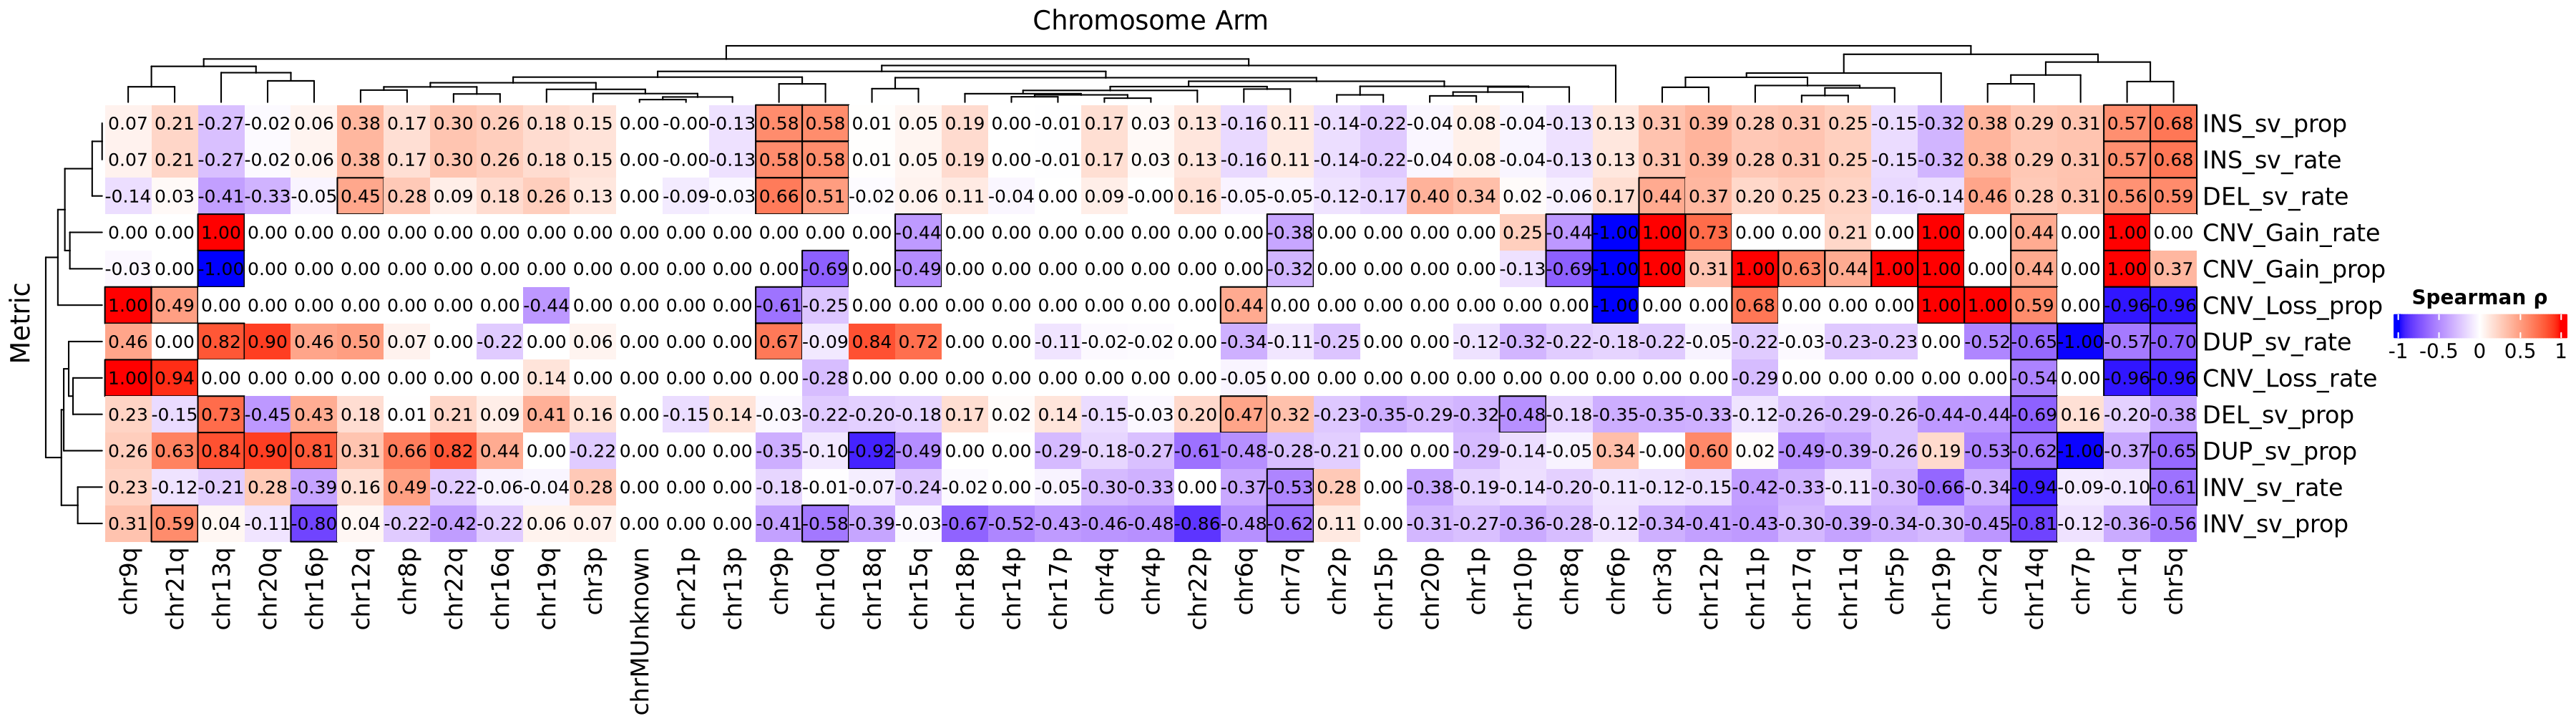

In [176]:
library(ComplexHeatmap)
library(circlize)
library(dplyr)
library(tidyr)
library(grid)

options(repr.plot.width = 18, repr.plot.height = 5, repr.plot.res = 200)

# pivot into matrices
mat_cor <- cor_results %>% 
  select(metric, chr_arm, cor) %>% 
  pivot_wider(names_from = chr_arm, values_from = cor) %>% 
  column_to_rownames("metric") %>% 
  as.matrix()

mat_p <- cor_results %>% 
  select(metric, chr_arm, p) %>% 
  pivot_wider(names_from = chr_arm, values_from = p) %>% 
  column_to_rownames("metric") %>% 
  as.matrix()

# define blue–white–red for correlation
col_fun <- colorRamp2(c(-1, 0, 1), c("blue", "white", "red"))

Heatmap(
  mat_cor,
  name = "Spearman ρ",
  col = col_fun,
  rect_gp = gpar(col = NA),            # base tiles no border
  cell_fun = function(j, i, x, y, width, height, fill) {
    # draw filled tile
    grid.rect(x = x, y = y, width = width, height = height,
              gp = gpar(fill = fill, col = NA))
    # add correlation text
    grid.text(sprintf("%.2f", mat_cor[i, j]), x = x, y = y,
              gp = gpar(fontsize = 9))
     #outline if p < 0.05
    if (!is.na(mat_p[i, j]) && mat_p[i, j] < 0.05) {
      grid.rect(x = x, y = y, width = width, height = height,
                gp = gpar(fill = NA, col = "black", lwd = 1))
    }
  },
  cluster_rows = TRUE,
  cluster_columns = TRUE,
  row_title = "Metric",
  column_title = "Chromosome Arm",
  heatmap_legend_param = list(
    title = "Spearman ρ",
    direction = "horizontal",
    title_position = "topcenter"
  )
)
